# 单细胞多模态数据的马赛克整合分析（mosaic integration）入门教程

本教程面向零基础读者，使用一个 DOGMA / CITE-seq / ASAP-seq 多模态数据文件讲解：什么是单细胞多模态数据、为什么会出现 mosaic integration 问题，以及如何把 RNA、ATAC、ADT 这些不同模态整合到同一个低维空间中。

本教程会得到以下结果：

- 读懂 DOGMA / CITE-seq / ASAP-seq 数据里每个 batch 有哪些模态；
- 画出 `batch × modality` 的数据结构示意图；
- 完成 RNA、ATAC、ADT 的基础预处理；
- 在 Notebook 中完成完整数据的 scMoMaT、MIDAS、scVAEIT 训练；
- 保存完整数据的 `.h5ad` 结果、UMAP 图片和状态表；
- 学会如何把同样流程迁移到自己的 mosaic integration 数据集。


## 1. 什么是单细胞多模态数据

“单细胞”指的是我们不是把一大团细胞混在一起测量，而是尽量把每个细胞分开，分别记录它的分子信息。每一行通常代表一个细胞，每一列代表一个分子特征。

常见模态包括：

- **RNA / gene expression**：基因表达。可以粗略理解为“这个细胞正在使用哪些基因”。
- **ATAC / chromatin accessibility**：染色质开放性。可以粗略理解为“基因组哪些区域更容易被调控机器接近”。
- **ADT / antibody-derived tag**：抗体标签，常见于 CITE-seq。可以粗略理解为“细胞表面或内部某些蛋白的检测信号”。

同一个细胞可以同时测到多个模态。例如一个细胞既有 RNA 表达，又有表面蛋白，也可能有 ATAC 开放区域。多模态数据的价值在于：不同模态从不同角度描述同一个细胞，整合后通常能更稳健地识别细胞类型和状态。


## 2. 什么是 mosaic integration

在普通单模态整合中，我们可能只有多个 scRNA-seq batch，目标是消除 batch effect，同时保留真实的细胞类型差异。

在 paired multi-omics integration 中，每个细胞都同时测到了多个模态，例如每个细胞都有 RNA 和 ATAC。

**mosaic integration** 更复杂：不同 batch 只测到部分模态，像马赛克一样拼在一起。例如：

- batch A 有 RNA + ATAC + ADT；
- batch B 只有 RNA + ADT；
- batch C 只有 ATAC + ADT。

这时不能简单把矩阵横向拼接，因为有些 batch 的某些模态根本不存在。如果把缺失模态直接填 0，模型可能误以为这些细胞真的“没有表达/没有开放”，而不是“没有测到”。mosaic integration 的核心任务，就是在这种模态缺失的情况下，利用共享模态作为桥梁，把所有细胞放进一个可比较的低维空间。

好的整合结果可以用于 UMAP 可视化、聚类、细胞类型注释、批次校正、跨模态补全和下游差异分析。但要注意：batch mixing 好不一定代表生物学结果好；如果不同 cell type 被强行混在一起，可能是过度整合。


## 3. 环境配置

建议新建独立 conda 环境，原因是单细胞工具之间常有 PyTorch、TensorFlow、Numpy、CUDA 版本冲突。独立环境可以避免影响服务器已有项目。

本教程实际创建并使用的环境：

```bash
conda create -y -n mosaic_tutorial_2026 python=3.10 pip
conda activate mosaic_tutorial_2026
conda install -y -c conda-forge scanpy anndata muon h5py numpy pandas scipy scikit-learn matplotlib seaborn umap-learn leidenalg python-igraph ipykernel jupyter tqdm networkx nbformat nbclient
pip install scmomat==0.2.2
pip install scVAEIT==1.1.1 tensorflow==2.15.1
pip install scmidas==0.3.0
pip install torch==2.7.1 torchvision==0.22.1 torchaudio==2.7.1 --index-url https://download.pytorch.org/whl/cu126
python -m ipykernel install --user --name mosaic_tutorial_2026 --display-name "Python (mosaic_tutorial_2026)"
```

当前服务器上最终验证的关键版本：

- Python 3.10.20；
- `scanpy 1.11.5`、`anndata 0.10.x/0.11.x`、`muon`、`h5py`、`numpy 1.26.4`；
- `scmomat 0.2.2`；
- `scmidas 0.3.0`。早期 `scmidas 0.1.15` 可安装但不包含本教程需要的 `MIDAS.configure_data_from_mdata`，因此升级到 0.3.0；
- `scVAEIT 1.1.1`、`tensorflow 2.15.1`；
- `torch 2.7.1+cu126`。

当前服务器上的特殊情况与排查：

- GitHub 访问不稳定，所以实际安装优先使用 PyPI 包；
- PyTorch 需要优先加载 conda/PyTorch 自带 CUDA 12.6 动态库，否则系统 CUDA 12.0 的 `libnvJitLink` 可能抢先加载并导致符号不匹配；
- Jupyter kernel 的 `kernel.json` 已加入 conda 环境库路径，避免系统 `libstdc++` 版本过旧导致导入失败；
- 如果遇到 `ImportError: libcusparse.so.12 ... __nvJitLinkGetErrorLog_12_6`，先检查 `LD_LIBRARY_PATH` 是否把 `$CONDA_PREFIX/lib/python3.10/site-packages/nvidia/nvjitlink/lib` 放在系统 CUDA 路径前。

常见排查顺序：确认 `which python` 是否指向 `mosaic_tutorial_2026`，再逐个测试 `import scanpy`、`import torch`、`import scmidas`、`import tensorflow`、`from scVAEIT import VAEIT`。


## 4. 导入 Python 包

下面的代码导入本教程需要的包。每个包的用途如下：

- `h5py`：读取原始 h5 文件结构；
- `numpy/pandas/scipy`：处理矩阵和表格；
- `scanpy/anndata`：单细胞对象、邻居图、UMAP 和保存 h5ad；
- `matplotlib/seaborn`：画图；
- `torch/tensorflow`：深度学习框架，分别被 scMoMaT/MIDAS 和 scVAEIT 使用。


In [1]:
from pathlib import Path
import os
import json
import pickle
import random
import warnings

import h5py
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import anndata as ad

warnings.filterwarnings("ignore", category=FutureWarning)

# Configure paths without hard-coding a machine-specific location.
# Before running the notebook on a server, set these environment variables if needed:
#   MOSAIC_TUTORIAL_DATA: path to the input h5 file
#   MOSAIC_TUTORIAL_OUT:  directory for all generated results
DATA_PATH = Path(os.environ.get("MOSAIC_TUTORIAL_DATA", "dogma_cite_asap.h5"))
OUT_DIR = Path(os.environ.get("MOSAIC_TUTORIAL_OUT", "mosaic_tutorial_result"))
FIG_DIR = OUT_DIR / "figures"
FULL_DIR = OUT_DIR / "full_results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
FULL_DIR.mkdir(parents=True, exist_ok=True)

SEED = 2026
np.random.seed(SEED)
random.seed(SEED)

print("Input data file exists:", DATA_PATH.exists())
print("Output directory is ready.")


Input data file exists: True
Output directory is ready.


## 5. 读取真实数据并检查 h5 结构

这个输入 h5 文件不是标准 `.h5ad`，而是自定义 HDF5 文件。RNA 和 ATAC peaks 使用稀疏矩阵的 `data / indices / indptr / shape` 存储；ADT 是普通二维矩阵。

先只读打开文件，打印根目录字段、矩阵维度、样本大小和元信息字段。


In [2]:
def decode_array(values):
    return np.array([x.decode("utf-8") if isinstance(x, bytes) else str(x) for x in values])

with h5py.File(DATA_PATH, "r") as f:
    print("root keys:")
    for key in f.keys():
        obj = f[key]
        shape = getattr(obj, "shape", None)
        dtype = getattr(obj, "dtype", None)
        print(f"  {key:15s} shape={shape} dtype={dtype}")

    sample_sizes = f["sample_sizes"][()]
    print("\nsample_sizes:", sample_sizes, "总细胞数:", sample_sizes.sum())
    print("RNA.shape:", f["RNA.shape"][()])
    print("peaks.shape:", f["peaks.shape"][()])
    print("ADT.shape:", f["ADT"].shape)
    print("cell_types 前 10 个:", decode_array(f["cell_types"][:10]))


root keys:
  ADT             shape=(30987, 227) dtype=float64
  ADT_names       shape=(227,) dtype=object
  RNA.data        shape=(11066013,) dtype=float64
  RNA.indices     shape=(11066013,) dtype=int32
  RNA.indptr      shape=(3661,) dtype=int32
  RNA.shape       shape=(2,) dtype=int64
  batches         shape=(30987, 2) dtype=float64
  cell_ids        shape=(30987,) dtype=object
  cell_types      shape=(30987,) dtype=object
  gene_names      shape=(3660,) dtype=object
  id_X_cite       shape=(2374,) dtype=int64
  id_X_dogma      shape=(2166,) dtype=int64
  id_Y_asap       shape=(227,) dtype=int64
  id_Y_cite       shape=(227,) dtype=int64
  id_Y_dogma      shape=(208,) dtype=int64
  id_Z_asap       shape=(38152,) dtype=int64
  id_Z_dogma      shape=(26765,) dtype=int64
  peak_names      shape=(38711,) dtype=object
  peaks.data      shape=(104909310,) dtype=float64
  peaks.indices   shape=(104909310,) dtype=int32
  peaks.indptr    shape=(38712,) dtype=int32
  peaks.shape     shape=(2,

## 6. 数据结构检查与示意图

根据 `sample_sizes`，文件中的细胞顺序分成三段：DOGMA、CITE-seq、ASAP-seq。结合 `id_X_* / id_Y_* / id_Z_*` 字段可以判断每种技术实际包含哪些 feature 和模态：

- `X` 表示 RNA；
- `Y` 表示 ADT；
- `Z` 表示 ATAC peaks。

下面自动生成数据结构表，并画出 batch × modality 示意图。彩色块表示该 batch 测到了该模态，空白表示缺失。


,technology,n_cells,RNA,RNA_n_features,ADT,ADT_n_features,ATAC,ATAC_n_features
0,DOGMA,13763,1,2166,1,208,1,26765
1,CITE-seq,8689,1,2374,1,227,0,0
2,ASAP-seq,8535,0,0,1,227,1,38152


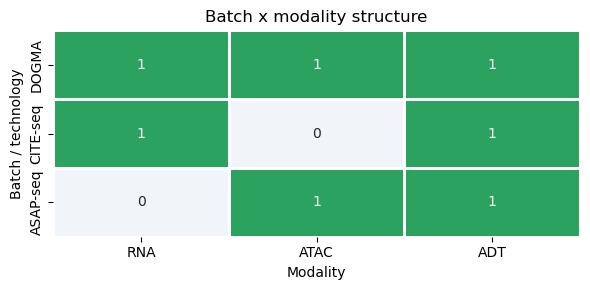

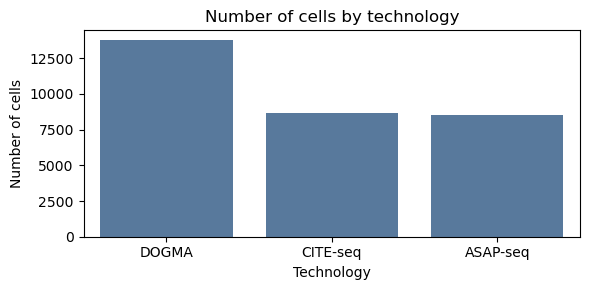

In [3]:
TECH_ORDER = ["DOGMA", "CITE-seq", "ASAP-seq"]
TECH_KEY = {"DOGMA": "dogma", "CITE-seq": "cite", "ASAP-seq": "asap"}
MODALITY_KEYS = {"RNA": "X", "ADT": "Y", "ATAC": "Z"}

with h5py.File(DATA_PATH, "r") as f:
    sample_sizes = f["sample_sizes"][()]
    cell_types = decode_array(f["cell_types"][:])
    batches_raw = f["batches"][()]
    n_cells_total = int(sample_sizes.sum())

    starts = np.r_[0, np.cumsum(sample_sizes)[:-1]]
    ends = np.cumsum(sample_sizes)

    structure_rows = []
    for tech, start, end in zip(TECH_ORDER, starts, ends):
        key = TECH_KEY[tech]
        row = {"technology": tech, "n_cells": int(end - start)}
        for modality, prefix in MODALITY_KEYS.items():
            h5_key = f"id_{prefix}_{key}"
            row[modality] = int(h5_key in f)
            row[f"{modality}_n_features"] = int(len(f[h5_key])) if h5_key in f else 0
        structure_rows.append(row)

structure_df = pd.DataFrame(structure_rows)
display(structure_df)

fig, ax = plt.subplots(figsize=(6, 3))
heat = structure_df.set_index("technology")[["RNA", "ATAC", "ADT"]]
sns.heatmap(heat, annot=True, cbar=False, cmap=sns.color_palette(["#f1f5f9", "#2ca25f"], as_cmap=True), linewidths=1, linecolor="white", ax=ax)
ax.set_title("Batch x modality structure")
ax.set_xlabel("Modality")
ax.set_ylabel("Batch / technology")
plt.tight_layout()
plt.savefig(FIG_DIR / "batch_modality_heatmap.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(6, 3))
sns.barplot(data=structure_df, x="technology", y="n_cells", ax=ax, color="#4c78a8")
ax.set_title("Number of cells by technology")
ax.set_xlabel("Technology")
ax.set_ylabel("Number of cells")
plt.tight_layout()
plt.savefig(FIG_DIR / "cell_count_by_technology.png", dpi=180)
plt.show()


## 7. 数据预处理

不同模态不能完全使用同一种预处理方式：

- RNA 是基因表达计数，常用 library size normalize、log transform、HVG、scale、PCA。
- ATAC 是稀疏的 peaks 计数，常用 TF-IDF、LSI/SVD。
- ADT 是蛋白标签信号，常用 log 或 centered log-ratio 风格的归一化，再 scale。

下面定义几个教学用函数，并创建一个小规模数据对象。小规模模式不是最终分析，只是让初学者能快速跑完全部流程。


In [4]:
def load_raw_matrices(path):
    with h5py.File(path, "r") as f:
        rna = sparse.csc_matrix(
            (f["RNA.data"][()], f["RNA.indices"][()], f["RNA.indptr"][()]),
            shape=tuple(f["RNA.shape"][()]),
        ).tocsr()
        atac = sparse.csc_matrix(
            (f["peaks.data"][()], f["peaks.indices"][()], f["peaks.indptr"][()]),
            shape=tuple(f["peaks.shape"][()]),
        ).tocsr()
        adt = np.asarray(f["ADT"][()])
        info = {
            "sample_sizes": f["sample_sizes"][()],
            "cell_types": decode_array(f["cell_types"][:]),
            "cell_ids": decode_array(f["cell_ids"][:]),
            "gene_names": decode_array(f["gene_names"][:]),
            "peak_names": decode_array(f["peak_names"][:]),
            "adt_names": decode_array(f["ADT_names"][:]),
            "ids": {key: f[key][()] for key in f.keys() if key.startswith("id_")},
        }
    return rna, atac, adt, info

rna_raw, atac_raw, adt_raw, info = load_raw_matrices(DATA_PATH)
print("RNA:", rna_raw.shape, "ATAC:", atac_raw.shape, "ADT:", adt_raw.shape)


RNA: (30987, 3660) ATAC: (30987, 38711) ADT: (30987, 227)


In [5]:
def tfidf_lsi(atac_counts, n_components=30, random_state=SEED):
    """ATAC 常用的简化 TF-IDF + SVD/LSI。"""
    X = atac_counts.astype(float).tocsr()
    cell_sums = np.asarray(X.sum(axis=1)).ravel()
    cell_sums[cell_sums == 0] = 1
    tf = X.multiply(1 / cell_sums[:, None])
    n_cells = X.shape[0]
    feature_detected = np.asarray((X > 0).sum(axis=0)).ravel()
    idf = np.log1p(n_cells / np.maximum(feature_detected, 1))
    tfidf = tf.multiply(idf)
    svd = TruncatedSVD(n_components=n_components, random_state=random_state)
    return svd.fit_transform(tfidf)

def choose_demo_indices(sample_sizes, cells_per_tech=300):
    starts = np.r_[0, np.cumsum(sample_sizes)[:-1]]
    ends = np.cumsum(sample_sizes)
    selected = []
    tech_labels = []
    for tech, start, end in zip(TECH_ORDER, starts, ends):
        n = min(cells_per_tech, int(end - start))
        idx = np.random.choice(np.arange(start, end), size=n, replace=False)
        selected.append(idx)
        tech_labels.extend([tech] * n)
    return selected, np.array(tech_labels)

CELLS_PER_TECH = 300
selected_by_tech, technology = choose_demo_indices(info["sample_sizes"], CELLS_PER_TECH)
selected_all = np.concatenate(selected_by_tech)

obs = pd.DataFrame({
    "cell_id": info["cell_ids"][selected_all],
    "cell_type": info["cell_types"][selected_all],
    "technology": technology,
    "batch": technology,
})
obs.head()


,cell_id,cell_type,technology,batch
0,ATGGACAAGTTGGCCA-1,CD4 T,DOGMA,DOGMA
1,GACTATTCAGGCGATA-2,CD4 T,DOGMA,DOGMA
2,GATGCGACAGAGGCTA-1,other T,DOGMA,DOGMA
3,CCCTCATAGTTGCCTC-2,CD4 T,DOGMA,DOGMA
4,GTTAACCAGGTCCTGA-1,other T,DOGMA,DOGMA


## 8. 在 Notebook 中构建完整数据输入

Mosaic integration 的重点不是要求所有 batch 都有完全相同的模态，也不是要求所有模态共享 feature。真实 mosaic 数据通常是：

- 有些 batch 有 RNA，有些 batch 没有 RNA；
- 有些 batch 有 ATAC，有些 batch 没有 ATAC；
- 同一个 modality 内也可能存在不同实验得到的 feature 集差异。

在具体软件实现中，我们仍然需要给每个 modality 一个清楚的 feature 坐标系统，模型才知道每一列代表什么。本教程采用一个稳健、适合初学者理解的处理方式：

- RNA：在包含 RNA 的 batch 中保留可对齐的 RNA feature；
- ADT：在包含 ADT 的 batch 中保留可对齐的 protein/ADT feature；
- ATAC：在包含 ATAC 的 batch 中保留可对齐的 peak/region feature，并按染色体拆成 block 供 MIDAS 使用；
- 对没有某个 modality 的 batch，不人为伪造观测值，而是通过 MuData/mask 告诉模型该 modality 缺失。

也就是说，下面的数据整理是为了满足软件输入格式和清晰教学，不代表 mosaic integration 理论上要求“全局共同特征”。如果换成自己的数据，应优先保留可靠可解释的 feature 坐标；只有在某个工具明确要求统一矩阵时，才做必要的 feature 对齐或 padding。

In [7]:
import muon as mu

def decode_feature_name(value):
    if isinstance(value, bytes):
        return value.decode("utf-8")
    return str(value)

def peak_chromosome(peak_name):
    text = decode_feature_name(peak_name)
    if ":" in text:
        return text.split(":", 1)[0]
    return text.split("-", 1)[0]

def natural_chr_key(peak_name):
    chrom = peak_chromosome(peak_name)
    if chrom.startswith("chr"):
        chrom = chrom[3:]
    try:
        return int(chrom)
    except ValueError:
        return 10_000

sample_sizes = info["sample_sizes"]
starts = np.r_[0, np.cumsum(sample_sizes)[:-1]]
ends = np.cumsum(sample_sizes)
idx_dogma = np.arange(starts[0], ends[0])
idx_cite = np.arange(starts[1], ends[1])
idx_asap = np.arange(starts[2], ends[2])

common_rna_full = np.intersect1d(info["ids"]["id_X_dogma"], info["ids"]["id_X_cite"])
common_adt_full = np.intersect1d(
    np.intersect1d(info["ids"]["id_Y_dogma"], info["ids"]["id_Y_cite"]),
    info["ids"]["id_Y_asap"],
)
common_atac_full = np.intersect1d(info["ids"]["id_Z_dogma"], info["ids"]["id_Z_asap"])

peak_names_full = np.array([decode_feature_name(x) for x in info["peak_names"][common_atac_full]])
valid_chr = {f"chr{i}" for i in range(1, 23)}
keep_atac = np.array([peak_chromosome(x) in valid_chr for x in peak_names_full])
common_atac_full = common_atac_full[keep_atac]
peak_names_full = np.array([decode_feature_name(x) for x in info["peak_names"][common_atac_full]])
order = np.argsort([natural_chr_key(x) for x in peak_names_full], kind="stable")
common_atac_full = common_atac_full[order]
peak_names_full = peak_names_full[order]

obs_all = pd.DataFrame({
    "cell_id": info["cell_ids"],
    "cell_type": info["cell_types"],
})
obs_all["technology"] = np.repeat(TECH_ORDER, sample_sizes)
obs_all["batch"] = obs_all["technology"]
obs_all.index = obs_all["cell_id"].astype(str)

rna_cells = np.r_[idx_dogma, idx_cite]
adt_cells = np.r_[idx_dogma, idx_cite, idx_asap]
atac_cells = np.r_[idx_dogma, idx_asap]

adata_rna_full = ad.AnnData(
    X=rna_raw[rna_cells][:, common_rna_full].copy(),
    obs=obs_all.iloc[rna_cells].copy(),
    var=pd.DataFrame(index=info["gene_names"][common_rna_full].astype(str)),
)
adata_adt_full = ad.AnnData(
    X=sparse.csr_matrix(adt_raw[adt_cells][:, common_adt_full]),
    obs=obs_all.iloc[adt_cells].copy(),
    var=pd.DataFrame(index=info["adt_names"][common_adt_full].astype(str)),
)
adata_atac_full = ad.AnnData(
    X=atac_raw[atac_cells][:, common_atac_full].copy(),
    obs=obs_all.iloc[atac_cells].copy(),
    var=pd.DataFrame(index=pd.Index(peak_names_full.astype(str), name="peak")),
)

mdata_full = mu.MuData({"rna": adata_rna_full, "adt": adata_adt_full, "atac": adata_atac_full})
full_mdata_path = FULL_DIR / "dogma_cite_asap_common_features.h5mu"
mdata_full.write_h5mu(full_mdata_path)

chroms = pd.Series([peak_chromosome(x) for x in peak_names_full])
atac_dims = [int((chroms == f"chr{i}").sum()) for i in range(1, 23)]
common_feature_metadata = {
    "n_total_cells": int(len(obs_all)),
    "sample_sizes": [int(x) for x in sample_sizes],
    "rna_cells": int(adata_rna_full.n_obs),
    "rna_features": int(adata_rna_full.n_vars),
    "adt_cells": int(adata_adt_full.n_obs),
    "adt_features": int(adata_adt_full.n_vars),
    "atac_cells": int(adata_atac_full.n_obs),
    "atac_features": int(adata_atac_full.n_vars),
    "dims_x": {
        "rna": [int(adata_rna_full.n_vars)],
        "adt": [int(adata_adt_full.n_vars)],
        "atac": atac_dims,
    },
    "mdata_path": str(full_mdata_path),
}
with open(FULL_DIR / "common_feature_metadata.json", "w") as f:
    json.dump(common_feature_metadata, f, indent=2)

print("Full MuData saved:", full_mdata_path.name)
print("RNA:", adata_rna_full.shape, "ADT:", adata_adt_full.shape, "ATAC:", adata_atac_full.shape)
print("ATAC blocks:", atac_dims)


2026-06-05 14:15:18.378476: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-05 14:15:18.444193: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-05 14:15:18.444331: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-05 14:15:18.449626: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-05 14:15:18.469120: I tensorflow/core/platform/cpu_feature_guar

2026-06-05 14:15:19.430916: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


  self._update_attr_legacy(attr, axis, join_common, **kwargs)


Full MuData saved: dogma_cite_asap_common_features.h5mu
RNA: (22452, 880) ADT: (30987, 208) ATAC: (22298, 26206)
ATAC blocks: [2761, 2026, 1558, 858, 1178, 1608, 1296, 1000, 1021, 1205, 1363, 1436, 531, 1001, 885, 1116, 1614, 421, 1598, 745, 331, 654]


## 9. 方法一：scMoMaT

scMoMaT 是面向 mosaic single-cell multi-omics 的矩阵分解模型。它把不同 batch、不同模态的矩阵共同分解到共享低维空间中。输入形式是一个字典：每个模态对应一个列表，列表长度等于 batch 数；如果某个 batch 缺失某个模态，就填 `None`。

下面的代码在 Notebook 中直接完成完整数据训练流程：读取完整 MuData，按 batch 组织 RNA/ADT/ATAC，使用 scMoMaT 默认推荐参数训练，提取 latent embedding，并保存完整数据 UMAP。该单元会直接在完整数据集上训练模型，并把结果保存到教程输出目录。

**References and resources**

- Article: [scMoMaT jointly performs single cell mosaic integration and multi-modal bio-marker detection](https://www.nature.com/articles/s41467-023-36066-2)
- Code repository: [PeterZZQ/scMoMaT](https://github.com/PeterZZQ/scMoMaT)
- Tutorial: [scMoMaT demo notebook](https://github.com/PeterZZQ/scMoMaT/blob/main/demo_scmomat.ipynb)


> Runtime note: On this full dataset, scMoMaT with 4000 iterations took about 4-5 minutes on the tested GPU server. Runtime depends on GPU, CPU, selected features, and batch size.

Input sanity check...
Finished.


Epoch 1, Validating Loss: 361.7060
	 loss reconstruction: 0.36108
	 loss regularization: 0.63000


Epoch 1000, Validating Loss: 276.6573
	 loss reconstruction: 0.27662
	 loss regularization: 0.03784


Epoch 2000, Validating Loss: 272.0038
	 loss reconstruction: 0.27196
	 loss regularization: 0.03991


Epoch 3000, Validating Loss: 270.4745
	 loss reconstruction: 0.27042
	 loss regularization: 0.05403


Epoch 4000, Validating Loss: 269.5051
	 loss reconstruction: 0.26946
	 loss regularization: 0.04406


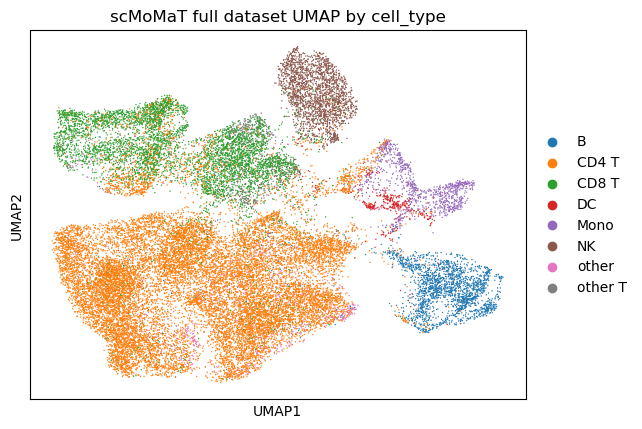

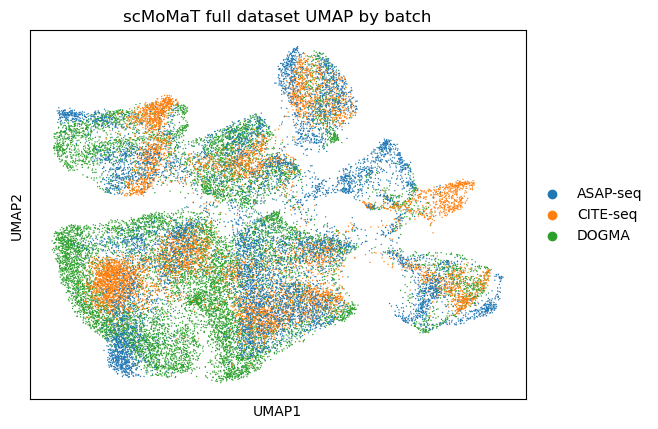

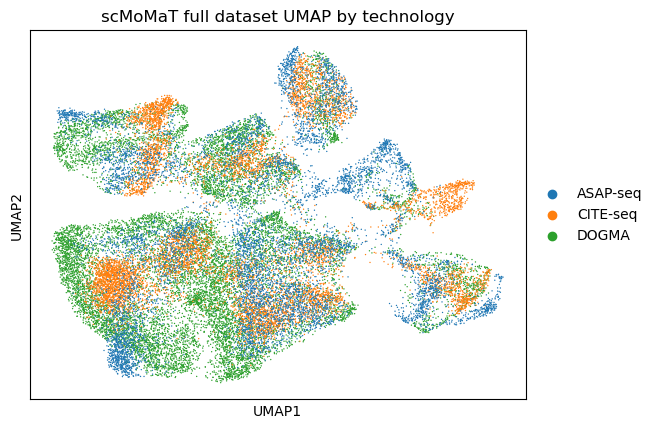

AnnData object with n_obs × n_vars = 30987 × 30
    obs: 'cell_id', 'cell_type', 'technology', 'batch'
    uns: 'neighbors', 'umap', 'cell_type_colors', 'batch_colors', 'technology_colors'
    obsm: 'X_scmomat', 'X_umap'
    obsp: 'distances', 'connectivities'


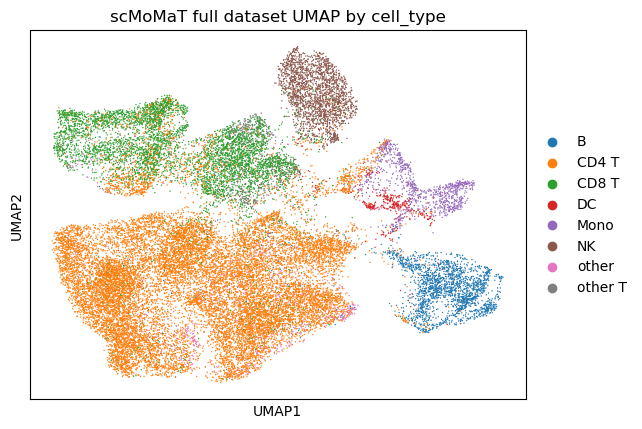

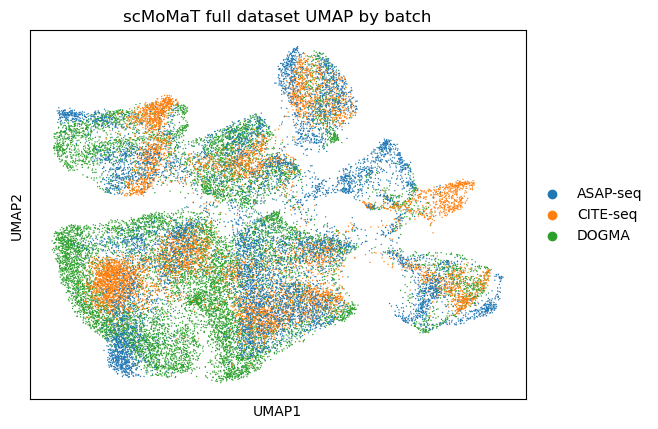

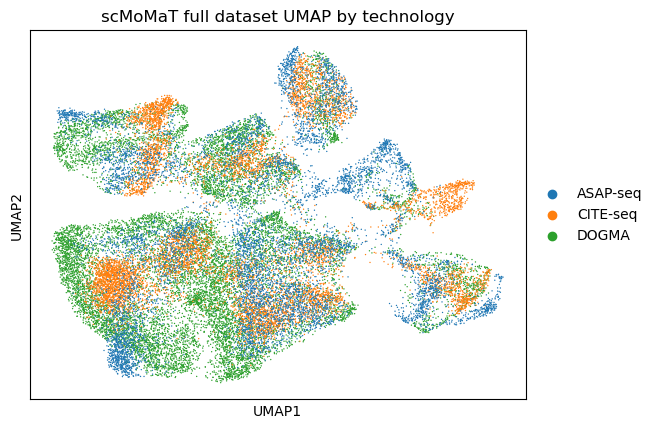

In [8]:
import time
import scipy.sparse as sp
import muon as mu
import torch
import scmomat

def dense_float32(x):
    if sp.issparse(x):
        x = x.toarray()
    return np.asarray(x, dtype=np.float32)

def run_scmomat_full_in_notebook():
    run_dir = FULL_DIR / "scmomat_full_default"
    result_path = run_dir / "scmomat_full.h5ad"
    status_path = run_dir / "status.json"
    mdata_path = FULL_DIR / "dogma_cite_asap_common_features.h5mu"

    run_dir.mkdir(parents=True, exist_ok=True)
    start_time = time.time()
    mdata = mu.read_h5mu(mdata_path)
    batches = ["DOGMA", "CITE-seq", "ASAP-seq"]
    adt_obs = mdata["adt"].obs.copy()

    counts = {"nbatches": len(batches), "rna": [], "protein": [], "atac": []}
    obs_frames = []

    for batch in batches:
        batch_cells = adt_obs.index[adt_obs["batch"].astype(str) == batch].tolist()
        obs_frames.append(adt_obs.loc[batch_cells, ["cell_id", "cell_type", "technology", "batch"]].copy())

        if batch in ["DOGMA", "CITE-seq"]:
            x_rna = dense_float32(mdata["rna"][batch_cells, :].X)
            x_rna = scmomat.preprocess(x_rna, modality="RNA", log=True).astype(np.float32)
            x_rna = np.nan_to_num(x_rna, nan=0.0, posinf=0.0, neginf=0.0)
            counts["rna"].append(x_rna)
        else:
            counts["rna"].append(None)

        x_adt = dense_float32(mdata["adt"][batch_cells, :].X)
        x_adt = scmomat.preprocess(x_adt, modality="ADT", log=True).astype(np.float32)
        x_adt = np.nan_to_num(x_adt, nan=0.0, posinf=0.0, neginf=0.0)
        counts["protein"].append(x_adt)

        if batch in ["DOGMA", "ASAP-seq"]:
            x_atac = dense_float32(mdata["atac"][batch_cells, :].X)
            x_atac = scmomat.preprocess(x_atac, modality="ATAC", log=False).astype(np.float32)
            x_atac = np.nan_to_num(x_atac, nan=0.0, posinf=0.0, neginf=0.0)
            counts["atac"].append(x_atac)
        else:
            counts["atac"].append(None)

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = scmomat.scmomat_model(
        counts=counts,
        K=30,
        batch_size=0.1,
        interval=1000,
        lr=0.01,
        lamb=0.001,
        seed=0,
        device=device,
    )
    losses = model.train_func(T=4000)
    latent = np.vstack(model.extract_cell_factors()).astype(np.float32)
    if not np.isfinite(latent).all():
        print("Warning: non-finite values detected in scMoMaT latent; replacing them with 0 before UMAP.")
        latent = np.nan_to_num(latent, nan=0.0, posinf=0.0, neginf=0.0)
    obs_full = pd.concat(obs_frames, axis=0)

    adata = ad.AnnData(X=latent, obs=obs_full)
    adata.obsm["X_scmomat"] = latent
    sc.pp.neighbors(adata, use_rep="X_scmomat", n_neighbors=30)
    sc.tl.umap(adata, random_state=0)
    adata.write_h5ad(result_path)

    for color in ["cell_type", "batch", "technology"]:
        sc.pl.umap(adata, color=color, show=False, title=f"scMoMaT full dataset UMAP by {color}")
        plt.savefig(FIG_DIR / f"scmomat_full_notebook_umap_{color}.png", dpi=180, bbox_inches="tight")
        plt.show()

    status = {
        "status": "success",
        "seconds": time.time() - start_time,
        "iterations": 4000,
        "n_cells": int(adata.n_obs),
        "latent_shape": list(latent.shape),
        "device": str(device),
        "torch": torch.__version__,
        "cuda": bool(torch.cuda.is_available()),
        "loss_last": float(losses[-1]) if len(losses) else None,
        "run_dir": run_dir.name,
    }
    status_path.write_text(json.dumps(status, indent=2, ensure_ascii=False))
    return adata

adata_scmomat = run_scmomat_full_in_notebook()
print(adata_scmomat)
if "X_umap" in adata_scmomat.obsm:
    for color in ["cell_type", "batch", "technology"]:
        sc.pl.umap(adata_scmomat, color=color, show=False, title=f"scMoMaT full dataset UMAP by {color}")
        plt.savefig(FIG_DIR / f"scmomat_full_notebook_umap_{color}.png", dpi=180, bbox_inches="tight")
        plt.show()


#### 结果可视化与比较

我们至少比较三类颜色：

- `cell_type`：看生物学细胞类型是否仍能分开；
- `batch`：看不同 batch 是否过度分离；
- `technology`：看 DOGMA、CITE-seq、ASAP-seq 是否能通过共享模态连接起来。

如果自己的数据没有这些字段，可以优先找类似字段，例如 `celltype`、`annotation`、`sample`、`donor`、`platform` 等。


## 10. 方法二：MIDAS

MIDAS 是基于深度生成模型的多模态整合工具。对于本教程的 mosaic 数据，关键是把完整数据整理成 MuData 对象，并明确告诉模型每个模态的 feature block 大小。

本教程使用的 MIDAS 设置包括：

- 用 `load_config()` 读取默认配置；
- 用 `MIDAS.configure_data_from_mdata(...)` 从 MuData 对象配置模型；
- 在每个 modality 的 `.obs` 中提供 `batch` 字段；
- 用 `dims_x` 告诉 MIDAS 每个模态的 feature 维度，其中 ATAC 按染色体拆成多个 block；
- 对 ATAC 使用 `transform={"atac": "binarize"}`；
- 训练后用 `model.predict(joint_latent=True, ...)` 提取共同 latent embedding。

下面的代码在 Notebook 中直接使用完整数据和官方示例常用 `max_epochs=2000` 训练 MIDAS，并把结果保存到教程输出目录。

**References and resources**

- Article: [Mosaic integration and knowledge transfer of single-cell multimodal data with MIDAS](https://www.nature.com/articles/s41587-023-02040-y)
- Code repository: [labomics/midas](https://github.com/labomics/midas)
- Tutorial: [MIDAS mosaic integration documentation](https://sc-midas-docs.readthedocs.io/en/latest/mosaic.html)


> Runtime note: On this full dataset, MIDAS with 2000 epochs took about 4.8 hours on the tested GPU server. MIDAS is the slowest method in this tutorial because it trains a deep generative model and also predicts imputed modality values.

Seed set to 42


Full MuData file is ready.
RNA cells/features: 22452 880
ADT cells/features: 30987 208
ATAC cells/features: 22298 26206
ATAC blocks: 22


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

predict:DOGMA:  80%|███████▉  | 43/54 [00:04<00:00, 17.38it/s]

predict:DOGMA:  85%|████████▌ | 46/54 [00:04<00:00, 18.95it/s]

predict:DOGMA:  91%|█████████ | 49/54 [00:04<00:00, 21.06it/s]

predict:DOGMA:  96%|█████████▋| 52/54 [00:04<00:00, 21.55it/s]

predict:DOGMA: 100%|██████████| 54/54 [00:04<00:00, 11.52it/s]

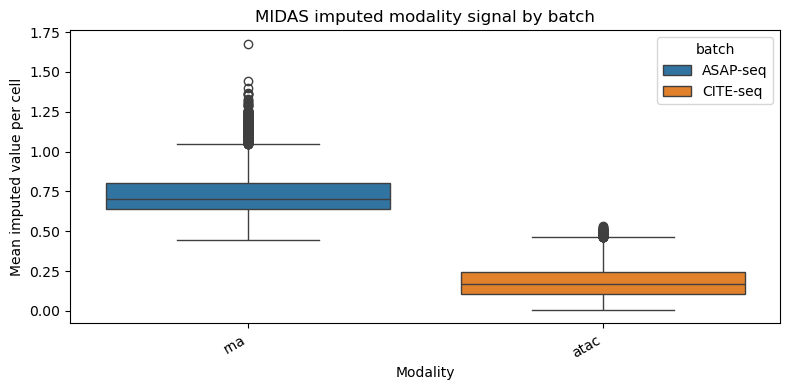

,batch,modality,availability,n_cells
0,ASAP-seq,rna,missing/imputed,8535
1,CITE-seq,atac,missing/imputed,8689


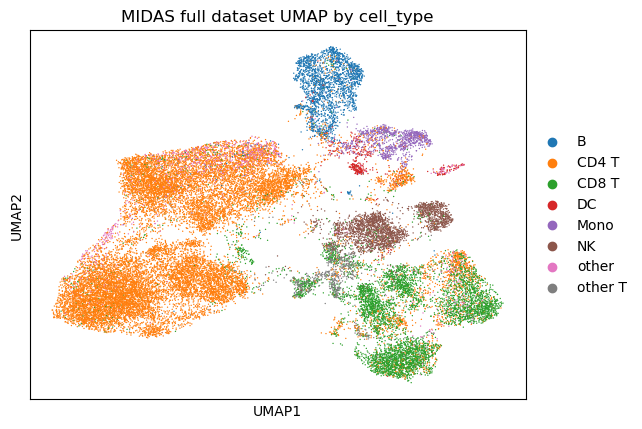

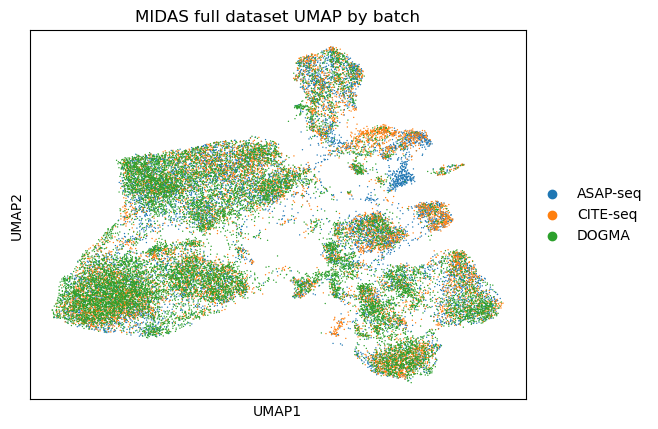

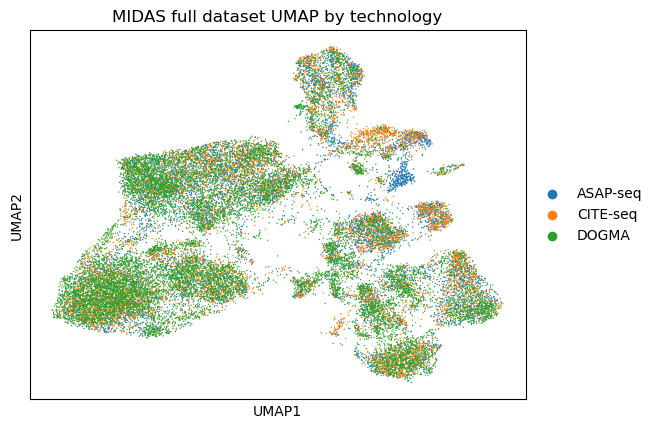

AnnData object with n_obs × n_vars = 30987 × 32
    obs: 'cell_id', 'cell_type', 'technology', 'batch'
    uns: 'neighbors', 'umap', 'cell_type_colors', 'batch_colors', 'technology_colors'
    obsm: 'X_midas', 'X_umap'
    obsp: 'distances', 'connectivities'


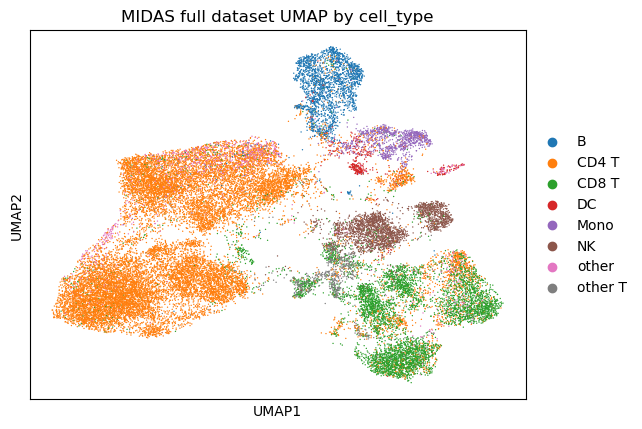

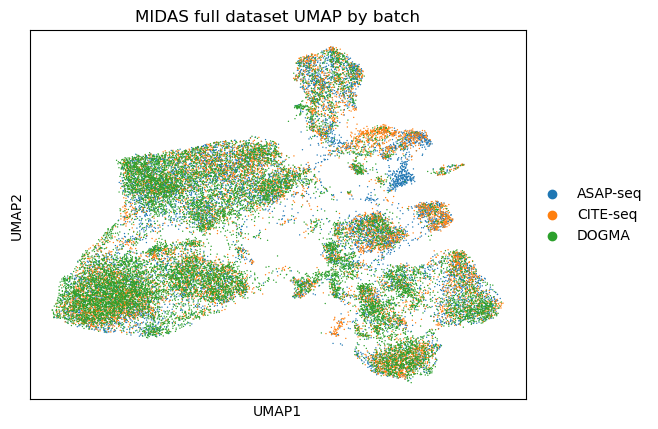

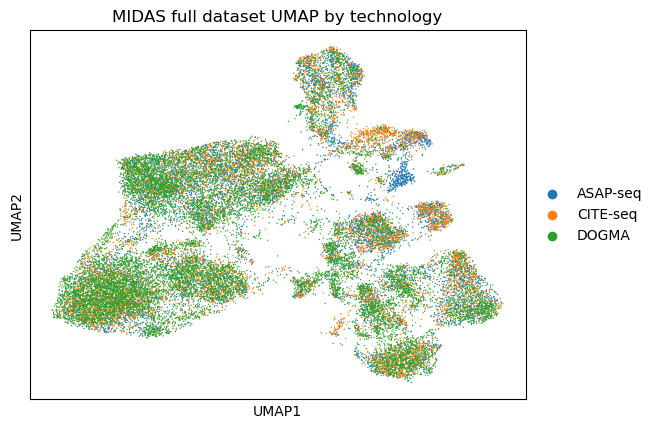

In [9]:
import lightning as L
from scmidas.config import load_config
from scmidas.model import MIDAS

metadata_path = FULL_DIR / "common_feature_metadata.json"
with open(metadata_path) as f:
    common_meta = json.load(f)

print("Full MuData file is ready.")
print("RNA cells/features:", common_meta["rna_cells"], common_meta["rna_features"])
print("ADT cells/features:", common_meta["adt_cells"], common_meta["adt_features"])
print("ATAC cells/features:", common_meta["atac_cells"], common_meta["atac_features"])
print("ATAC blocks:", len(common_meta["dims_x"]["atac"]))

def run_midas_full_in_notebook():
    run_dir = FULL_DIR / "midas_full_default_2000"
    result_path = run_dir / "midas_full.h5ad"
    status_path = run_dir / "status.json"

    run_dir.mkdir(parents=True, exist_ok=True)
    start_time = time.time()
    L.seed_everything(42)
    mdata = mu.read_h5mu(common_meta["mdata_path"])
    configs = load_config()

    saved_model_dir = run_dir / "trained_model"
    model = MIDAS.configure_data_from_mdata(
        mdata=mdata,
        batch_key="batch",
        dims_x=common_meta["dims_x"],
        configs=configs,
        transform={"atac": "binarize"},
        save_model_path=str(run_dir / "saved_models"),
        n_save=500,
        batch_size=256,
    )
    model.train(
        max_epochs=2000,
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        devices=1,
        default_root_dir=str(run_dir / "lightning"),
        log_every_n_steps=20,
        enable_checkpointing=True,
    )
    model.save(str(saved_model_dir))
    model_source = "trained_in_notebook"

    outputs = model.predict(
        joint_latent=True,
        input=False,
        batch_correct=False,
        impute=True,
        translate=False,
        mod_latent=False,
        return_in_memory=True,
        save_dir=str(run_dir / "predict_stream"),
        save_format="npy",
    )
    outputs_for_latent = outputs["memory"] if isinstance(outputs, dict) and "memory" in outputs else outputs

    latents = []
    obs_parts = []
    for batch_name, value in outputs_for_latent.items():
        if "z_c" in value and "joint" in value["z_c"]:
            z = value["z_c"]["joint"]
        elif "z" in value and "joint" in value["z"]:
            z = value["z"]["joint"]
        else:
            raise KeyError(f"Cannot find MIDAS joint latent for batch {batch_name}")
        if hasattr(z, "detach"):
            z = z.detach().cpu().numpy()
        z = np.asarray(z)
        latents.append(z)

        obs_batch = mdata["adt"].obs[mdata["adt"].obs["batch"].astype(str) == str(batch_name)].copy()
        obs_parts.append(obs_batch[["cell_id", "cell_type", "technology", "batch"]])

    latent = np.vstack(latents).astype(np.float32)
    obs_full = pd.concat(obs_parts, axis=0)

    imputation_rows = []
    for batch_name, value in outputs_for_latent.items():
        if "x_impt" not in value:
            continue
        obs_batch = mdata["adt"].obs[mdata["adt"].obs["batch"].astype(str) == str(batch_name)].copy()
        for modality, matrix in value["x_impt"].items():
            if hasattr(matrix, "detach"):
                matrix = matrix.detach().cpu().numpy()
            matrix = np.asarray(matrix, dtype=np.float32)
            if matrix.ndim != 2 or matrix.shape[0] != obs_batch.shape[0]:
                continue
            observed_names = set(mdata[modality].obs_names) if modality in mdata.mod else set()
            is_observed = obs_batch.index.to_series().isin(observed_names).to_numpy()
            score = np.nanmean(matrix, axis=1)
            temp = pd.DataFrame({
                "method": "MIDAS",
                "batch": obs_batch["batch"].astype(str).to_numpy(),
                "technology": obs_batch["technology"].astype(str).to_numpy(),
                "cell_type": obs_batch["cell_type"].astype(str).to_numpy(),
                "modality": modality,
                "availability": np.where(is_observed, "observed/reconstructed", "missing/imputed"),
                "mean_imputed_value": score,
            }, index=obs_batch.index)
            imputation_rows.append(temp)

    if imputation_rows:
        midas_imputation_df = pd.concat(imputation_rows, axis=0)
        midas_imputation_df.to_csv(run_dir / "midas_imputation_summary.csv")
        plot_df = midas_imputation_df[midas_imputation_df["availability"] == "missing/imputed"].copy()
        if plot_df.empty:
            plot_df = midas_imputation_df.copy()
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=plot_df, x="modality", y="mean_imputed_value", hue="batch")
        plt.title("MIDAS imputed modality signal by batch")
        plt.xlabel("Modality")
        plt.ylabel("Mean imputed value per cell")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.savefig(FIG_DIR / "midas_imputed_signal_by_batch.png", dpi=180, bbox_inches="tight")
        plt.show()
        display(plot_df.groupby(["batch", "modality", "availability"]).size().reset_index(name="n_cells"))

    adata = ad.AnnData(X=latent, obs=obs_full)
    adata.obsm["X_midas"] = latent
    sc.pp.neighbors(adata, use_rep="X_midas", n_neighbors=15)
    sc.tl.umap(adata, random_state=42)
    adata.write_h5ad(result_path)

    for color in ["cell_type", "batch", "technology"]:
        sc.pl.umap(adata, color=color, show=False, title=f"MIDAS full dataset UMAP by {color}")
        plt.savefig(FIG_DIR / f"midas_full_2000_notebook_umap_{color}.png", dpi=180, bbox_inches="tight")
        plt.show()

    status = {
        "status": "success",
        "max_epochs": 2000,
        "model_source": model_source,
        "seconds": time.time() - start_time,
        "n_cells": int(adata.n_obs),
        "latent_shape": list(latent.shape),
        "torch": torch.__version__,
        "cuda": bool(torch.cuda.is_available()),
        "run_dir": run_dir.name,
    }
    status_path.write_text(json.dumps(status, indent=2, ensure_ascii=False))
    return adata

adata_midas = run_midas_full_in_notebook()
print(adata_midas)
if "X_umap" in adata_midas.obsm:
    for color in ["cell_type", "batch", "technology"]:
        sc.pl.umap(adata_midas, color=color, show=False, title=f"MIDAS full dataset UMAP by {color}")
        plt.savefig(FIG_DIR / f"midas_full_2000_notebook_umap_{color}.png", dpi=180, bbox_inches="tight")
        plt.show()


## 11. 方法三：scVAEIT

scVAEIT 使用变分自编码器处理多模态缺失问题。它的关键输入是：

- `data`：所有模态拼接后的矩阵；
- `masks`：与 data 同形状的缺失矩阵。本版本中缺失值用 `-1` 表示，观测值用 `0` 表示；
- `config`：模型维度、每个模态 feature 数、latent 维度等。

下面的代码在 Notebook 中直接完成完整数据训练流程：构造 30,987 × 27,294 的 full data matrix，显式标记缺失模态，并保存完整数据 UMAP。

需要注意训练轮次的说法：当前安装版本的 `VAEIT.train()` 函数签名中 `num_epoch` 默认值是 200；同时，scVAEIT 官方教程示例中也能看到使用 300 epoch 的案例。因此，本教程直接采用当前安装 API 的默认值 `num_epoch=200`。训练轮次不要设得太小；如果只训练 1-5 epoch，模型通常还没有学到稳定的共同表示，UMAP 可视化会很差。若复现实验或参考特定官方教程，请按对应教程设置为 300 或更高。

**References and resources**

- Article: [Robust probabilistic modeling for single-cell multimodal mosaic integration and imputation via scVAEIT](https://pmc.ncbi.nlm.nih.gov/articles/PMC9894175/)
- Code repository: [jaydu1/scVAEIT](https://github.com/jaydu1/scVAEIT)
- Tutorial: [scVAEIT integration of three modalities](https://scvaeit.readthedocs.io/en/latest/tutorial/python/integration_3modalities.html)


> Runtime note: In this tutorial we use `num_epoch=200` for demonstration. A previous full 200-epoch run on this dataset took about 1.8 hours on the tested server. For real analyses, use about 300 epochs, or tune the epoch number with validation diagnostics and UMAP/cluster stability.

2026-06-05 19:08:23.372925: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Missingness (overall): 0.2781
Missingness (per row): mean=0.2781, min=0.0000, max=0.9601
Missingness (per column): mean=0.2781, min=0.0000, max=0.2804


namespace(beta_kl=0.01, beta_unobs=0.1, beta_reverse=0.0, beta_modal=array([1., 1., 1.], dtype=float32), p_modal=None, p_feat=0.2, uni_block_names=array(['M-0', 'M-1', 'M-2'], dtype='<U23'), block_names=array(['M-0', 'M-1', 'M-2'], dtype='<U23'), dist_block=array(['Gaussian', 'Gaussian', 'Gaussian'], dtype='<U8'), dim_block=array([  880,   208, 26206], dtype=int32), dim_block_enc=array([32, 32, 64], dtype=int32), dim_block_dec=array([32, 32, 64], dtype=int32), skip_conn=False, mean_vals=<tf.Tensor: shape=(27294,), dtype=float32, numpy=
array([-2.4851079e-06, -1.1848588e-05, -5.6446411e-06, ...,
        5.5871001e-06,  6.7893216e-06,  1.1923639e-05], dtype=float32)>, min_vals=<tf.Tensor: shape=(27294,), dtype=float32, numpy=
array([-3.550095 , -3.550095 , -3.550095 , ..., -3.0000706, -3.0000706,
       -3.0000706], dtype=float32)>, max_vals=<tf.Tensor: shape=(27294,), dtype=float32, numpy=
array([19.847664, 19.847664, 19.847664, ..., 13.91435 , 13.91435 ,
       13.91435 ], dtype=float3

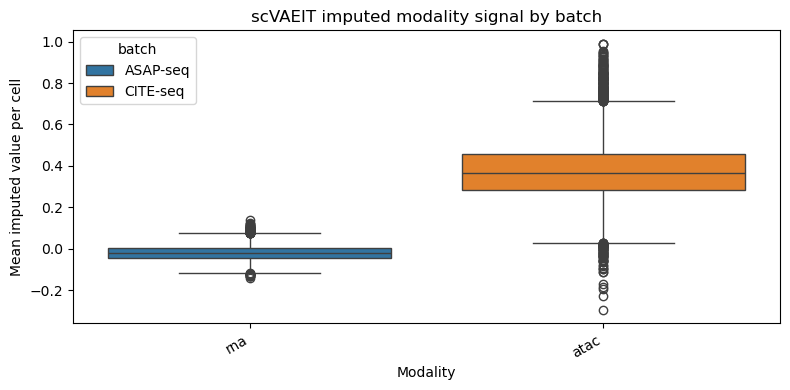

,batch,modality,availability,n_cells
0,ASAP-seq,rna,missing/imputed,8535
1,CITE-seq,atac,missing/imputed,8689


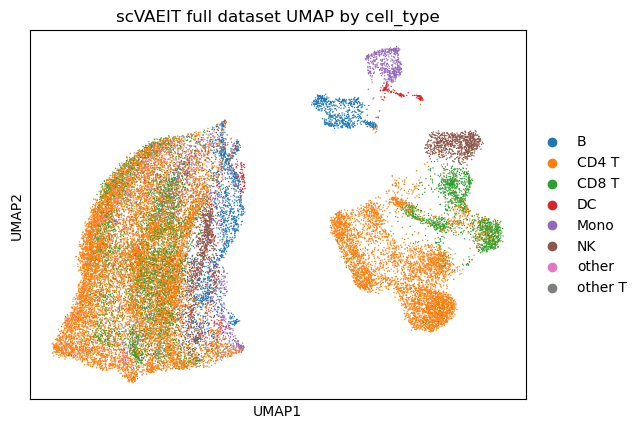

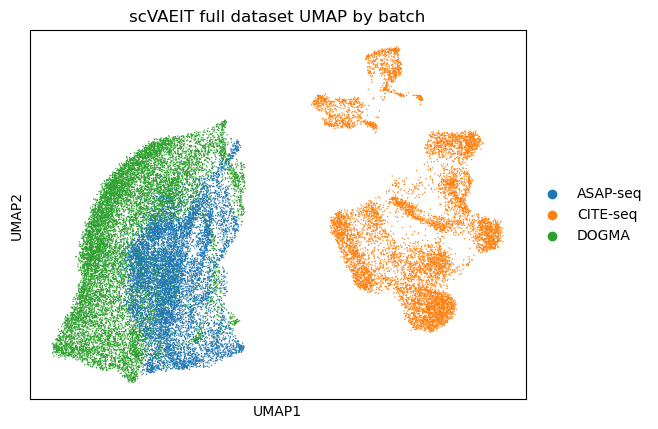

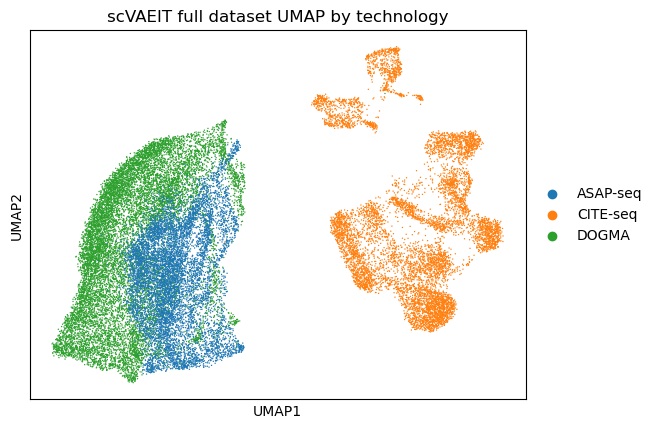

AnnData object with n_obs × n_vars = 30987 × 32
    obs: 'cell_id', 'cell_type', 'technology', 'batch'
    uns: 'neighbors', 'umap', 'cell_type_colors', 'batch_colors', 'technology_colors'
    obsm: 'X_scvaeait', 'X_umap'
    obsp: 'distances', 'connectivities'


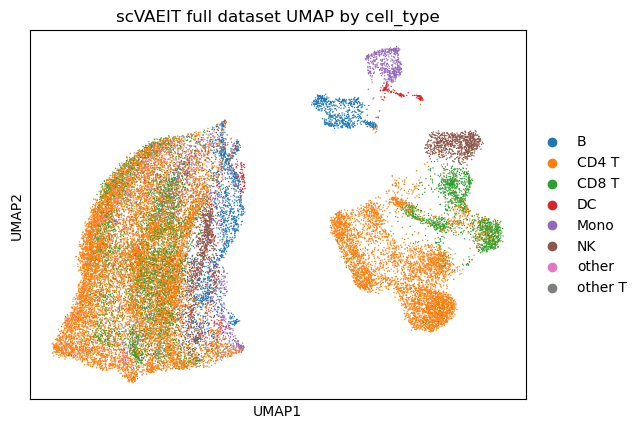

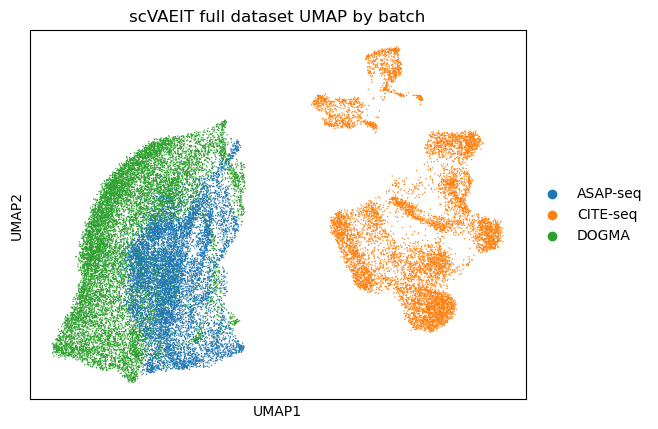

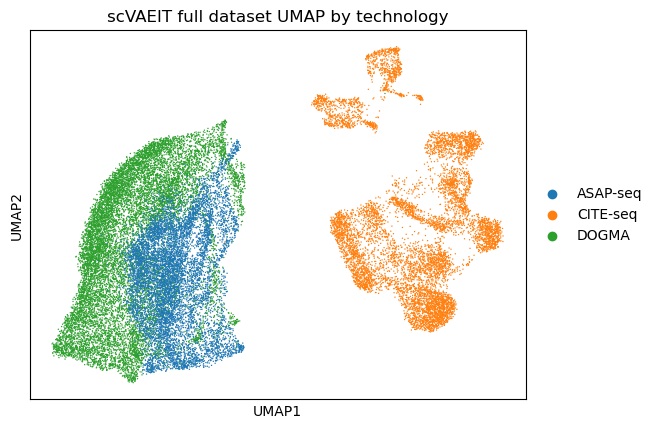

In [10]:
from scVAEIT import VAEIT, reset_random_seeds

def run_scvaeait_full_in_notebook():
    run_dir = FULL_DIR / "scvaeait_full_default"
    result_path = run_dir / "scvaeait_full.h5ad"
    status_path = run_dir / "status.json"
    mdata_path = FULL_DIR / "dogma_cite_asap_common_features.h5mu"

    run_dir.mkdir(parents=True, exist_ok=True)
    start_time = time.time()
    np.random.seed(1)
    reset_random_seeds(1)
    mdata = mu.read_h5mu(mdata_path)

    obs_full = mdata["adt"].obs[["cell_id", "cell_type", "technology", "batch"]].copy()
    all_cells = obs_full.index.tolist()
    n_rna = mdata["rna"].n_vars
    n_adt = mdata["adt"].n_vars
    n_atac = mdata["atac"].n_vars

    X = np.zeros((len(all_cells), n_rna + n_adt + n_atac), dtype=np.float32)
    masks = np.zeros_like(X, dtype=np.float32)
    masks[:] = -1.0

    rna_cells = mdata["rna"].obs_names.tolist()
    rna_pos = pd.Index(all_cells).get_indexer(rna_cells)
    X[rna_pos, :n_rna] = np.log1p(dense_float32(mdata["rna"].X))
    masks[rna_pos, :n_rna] = 0.0

    X[:, n_rna:n_rna+n_adt] = np.log1p(dense_float32(mdata["adt"].X))
    masks[:, n_rna:n_rna+n_adt] = 0.0

    atac_cells = mdata["atac"].obs_names.tolist()
    atac_pos = pd.Index(all_cells).get_indexer(atac_cells)
    X[atac_pos, n_rna+n_adt:] = np.log1p(dense_float32(mdata["atac"].X))
    masks[atac_pos, n_rna+n_adt:] = 0.0

    observed = masks == 0
    denom = np.maximum(observed.sum(axis=0), 1)
    means = (X * observed).sum(axis=0) / denom
    vars_ = ((X - means) ** 2 * observed).sum(axis=0) / denom
    X = ((X - means) / np.sqrt(vars_ + 1e-6)).astype(np.float32)
    X[masks == -1] = 0.0

    config = {
        "dim_input_arr": np.array([n_rna, n_adt, n_atac], dtype=np.int32),
        "dimensions": np.array([256, 128], dtype=np.int32),
        "dim_latent": 32,
        "dim_block_embed": 16,
        "dim_block": np.array([n_rna, n_adt, n_atac], dtype=np.int32),
        "dim_block_enc": np.array([32, 32, 64], dtype=np.int32),
        "dim_block_dec": np.array([32, 32, 64], dtype=np.int32),
        "dist_block": np.array(["Gaussian", "Gaussian", "Gaussian"]),
        "beta_kl": 0.01,
        "beta_unobs": 0.1,
    }

    model = VAEIT(config, X, masks)
    checkpoint_dir = run_dir / "checkpoint"
    # The installed scVAEIT API has num_epoch=200 as the function default.
    # For this tutorial, we use 200 epochs to keep the example manageable.
    # For real analyses, train for about 300 epochs or tune this value with validation diagnostics.
    model.train(
        num_epoch=200,
        batch_size=256,
        batch_size_inference=512,
        save_every_epoch=25,
        verbose=True,
        checkpoint_dir=str(checkpoint_dir),
        delete_existing=True,
    )
    model_source = "trained_in_notebook"
    latent = model.get_latent_z(num_repeat=1, batch_size_inference=512, training=False)
    if isinstance(latent, (list, tuple)):
        latent = latent[0]
    latent = np.asarray(latent, dtype=np.float32)

    denoised = model.get_denoised_data(
        zero_out=False,
        return_mean=True,
        num_repeat=1,
        L=20,
        batch_size_inference=512,
        training=False,
    )
    if isinstance(denoised, (list, tuple)):
        denoised = denoised[0]
    denoised = np.asarray(denoised, dtype=np.float32)

    modality_slices = {
        "rna": slice(0, n_rna),
        "adt": slice(n_rna, n_rna + n_adt),
        "atac": slice(n_rna + n_adt, n_rna + n_adt + n_atac),
    }
    scvaeait_rows = []
    for modality, slc in modality_slices.items():
        observed_names = set(mdata[modality].obs_names)
        is_observed = obs_full.index.to_series().isin(observed_names).to_numpy()
        score = np.nanmean(denoised[:, slc], axis=1)
        scvaeait_rows.append(pd.DataFrame({
            "method": "scVAEIT",
            "batch": obs_full["batch"].astype(str).to_numpy(),
            "technology": obs_full["technology"].astype(str).to_numpy(),
            "cell_type": obs_full["cell_type"].astype(str).to_numpy(),
            "modality": modality,
            "availability": np.where(is_observed, "observed/reconstructed", "missing/imputed"),
            "mean_imputed_value": score,
        }, index=obs_full.index))

    scvaeait_imputation_df = pd.concat(scvaeait_rows, axis=0)
    scvaeait_imputation_df.to_csv(run_dir / "scvaeait_imputation_summary.csv")
    plot_df = scvaeait_imputation_df[scvaeait_imputation_df["availability"] == "missing/imputed"].copy()
    if plot_df.empty:
        plot_df = scvaeait_imputation_df.copy()
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=plot_df, x="modality", y="mean_imputed_value", hue="batch")
    plt.title("scVAEIT imputed modality signal by batch")
    plt.xlabel("Modality")
    plt.ylabel("Mean imputed value per cell")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "scvaeait_imputed_signal_by_batch.png", dpi=180, bbox_inches="tight")
    plt.show()
    display(plot_df.groupby(["batch", "modality", "availability"]).size().reset_index(name="n_cells"))

    adata = ad.AnnData(X=latent, obs=obs_full)
    adata.obsm["X_scvaeait"] = latent
    sc.pp.neighbors(adata, use_rep="X_scvaeait", n_neighbors=30)
    sc.tl.umap(adata, random_state=1)
    adata.write_h5ad(result_path)

    for color in ["cell_type", "batch", "technology"]:
        sc.pl.umap(adata, color=color, show=False, title=f"scVAEIT full dataset UMAP by {color}")
        plt.savefig(FIG_DIR / f"scvaeait_full_notebook_umap_{color}.png", dpi=180, bbox_inches="tight")
        plt.show()

    status = {
        "status": "success",
        "seconds": time.time() - start_time,
        "num_epoch": 200,
        "model_source": model_source,
        "batch_size": 256,
        "n_cells": int(adata.n_obs),
        "latent_shape": list(latent.shape),
        "run_dir": run_dir.name,
    }
    status_path.write_text(json.dumps(status, indent=2, ensure_ascii=False))
    return adata

adata_scvaeait = run_scvaeait_full_in_notebook()
print(adata_scvaeait)
if "X_umap" in adata_scvaeait.obsm:
    for color in ["cell_type", "batch", "technology"]:
        sc.pl.umap(adata_scvaeait, color=color, show=False, title=f"scVAEIT full dataset UMAP by {color}")
        plt.savefig(FIG_DIR / f"scvaeait_full_notebook_umap_{color}.png", dpi=180, bbox_inches="tight")
        plt.show()


## 12. 方法运行总结

本 Notebook 中已经包含完整数据的 scMoMaT、MIDAS 和 scVAEIT 训练代码。所有结果都写入教程输出目录下的 `full_results` 和 `figures` 子目录。

完整训练设置如下：

- MIDAS：官方示例常用 `max_epochs=2000`；
- scMoMaT：默认参数 `K=30, batch_size=0.1, lr=0.01, lamb=0.001`，默认训练 `T=4000`；
- scVAEIT：当前安装 API 默认 `num_epoch=200`；部分官方教程示例使用 300。本教程使用 `num_epoch=200`，并显式构造缺失模态 mask。


In [11]:
FULL_RUNS = {
    "MIDAS full 2000 epochs": FULL_DIR / "midas_full_default_2000",
    "scMoMaT full default 4000 iterations": FULL_DIR / "scmomat_full_default",
    "scVAEIT full default 200 epochs": FULL_DIR / "scvaeait_full_default",
}

status_rows = []
for label, run_dir in FULL_RUNS.items():
    status_path = run_dir / "status.json"
    if status_path.exists():
        with open(status_path) as f:
            status = json.load(f)
        status_rows.append({
            "run": label,
            "status": status.get("status"),
            "seconds": round(status.get("seconds", 0), 1),
            "latent_shape": status.get("latent_shape"),
            "run_dir": run_dir.name,
        })
    else:
        status_rows.append({
            "run": label,
            "status": "not_finished",
            "seconds": None,
            "latent_shape": None,
            "run_dir": run_dir.name,
        })

full_status_df = pd.DataFrame(status_rows)
display(full_status_df)
full_status_df.to_csv(OUT_DIR / "mosaic_tutorial_full_run_status.csv", index=False)

# These variables point to the full default result objects created by the training cells above.
adata_midas_full = adata_midas
adata_scmomat_full = adata_scmomat
adata_scvaeait_full = adata_scvaeait

print("Full default results are stored in:")
for label, run_dir in FULL_RUNS.items():
    print(f"- {label}: result folder is ready")


,run,status,seconds,latent_shape,run_dir
0,MIDAS full 2000 epochs,success,17275.1,"[30987, 32]",midas_full_default_2000
1,scMoMaT full default 4000 iterations,success,263.4,"[30987, 30]",scmomat_full_default
2,scVAEIT full default 200 epochs,success,209.8,"[30987, 32]",scvaeait_full_default


Full default results are stored in:
- MIDAS full 2000 epochs: result folder is ready
- scMoMaT full default 4000 iterations: result folder is ready
- scVAEIT full default 200 epochs: result folder is ready


## 13. 下游分析示例：基于整合 latent embedding 做聚类

整合完成后，我们通常不会只看 UMAP。一个常见下游任务是：在整合后的低维表示上构建细胞邻接图，然后用 Leiden 算法做无监督聚类。

这一节演示三个问题：

- 聚类是否大致对应已知 cell type；
- 每个聚类是否被某一个 batch 完全主导；
- 不同方法得到的聚类结构是否稳定。


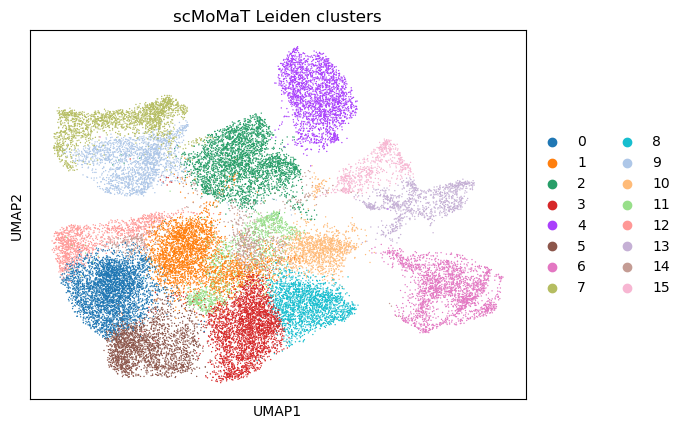

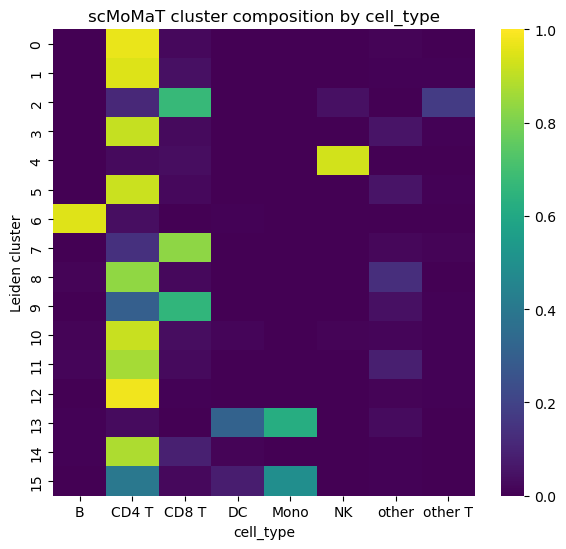

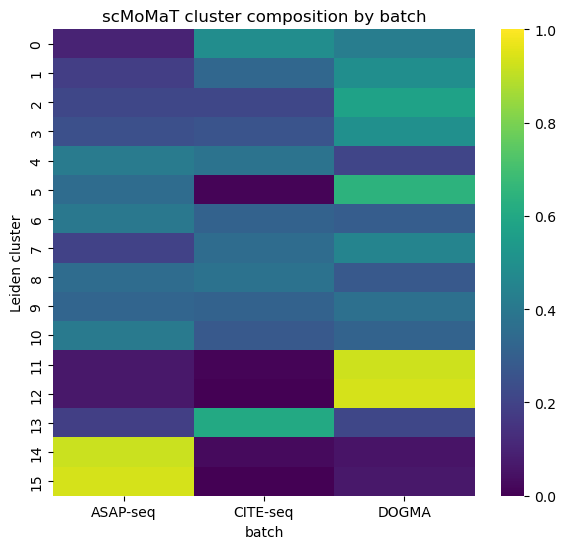

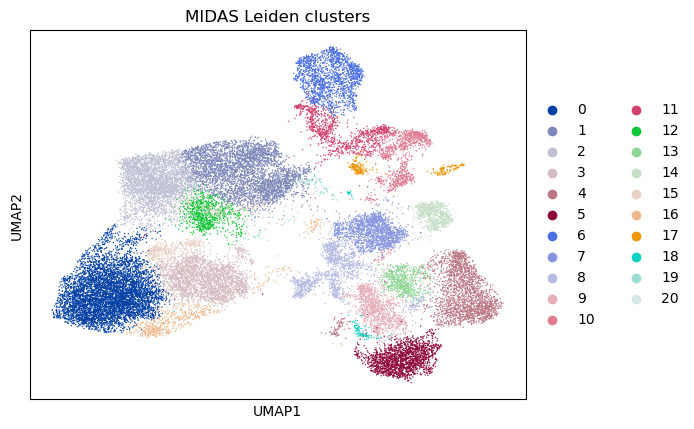

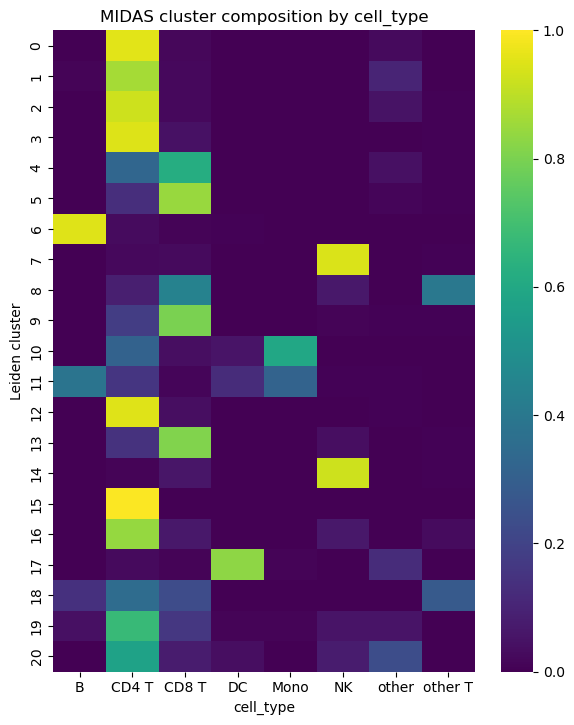

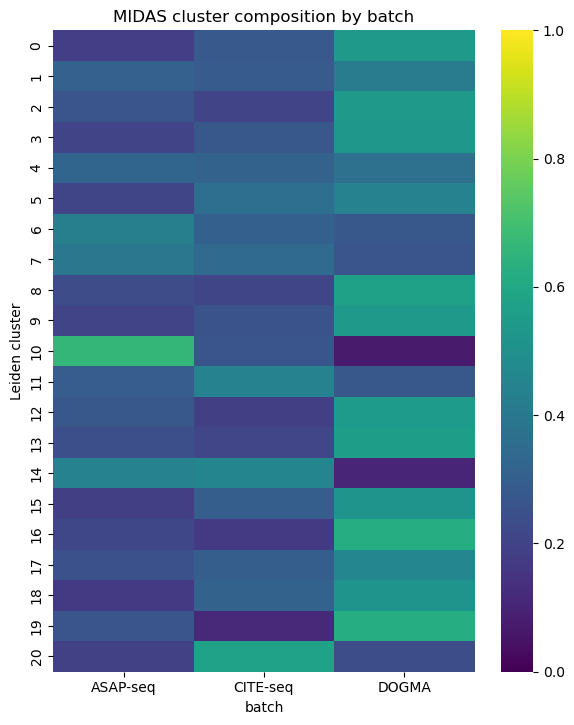

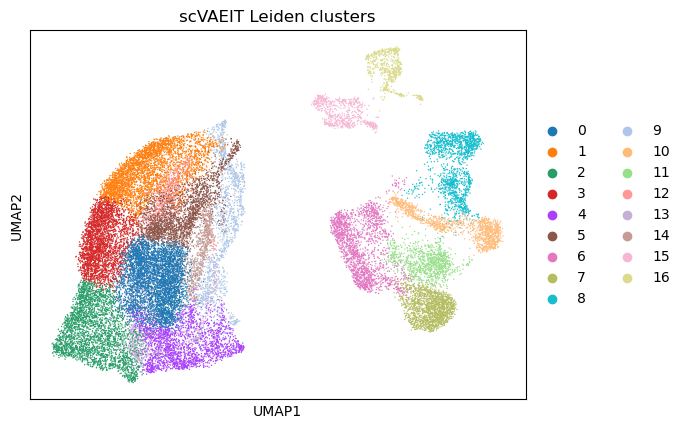

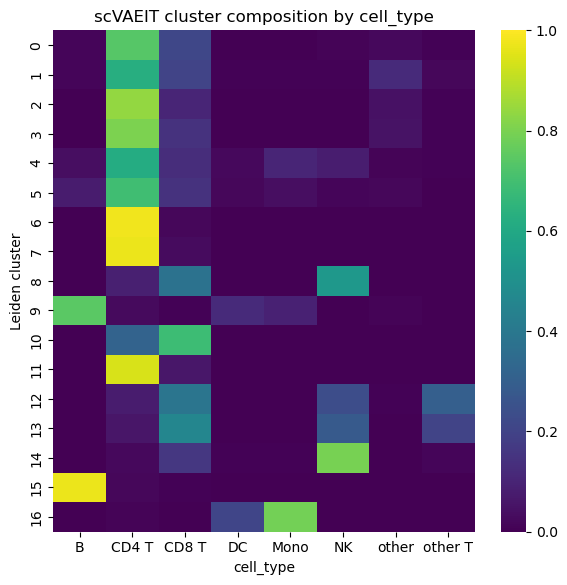

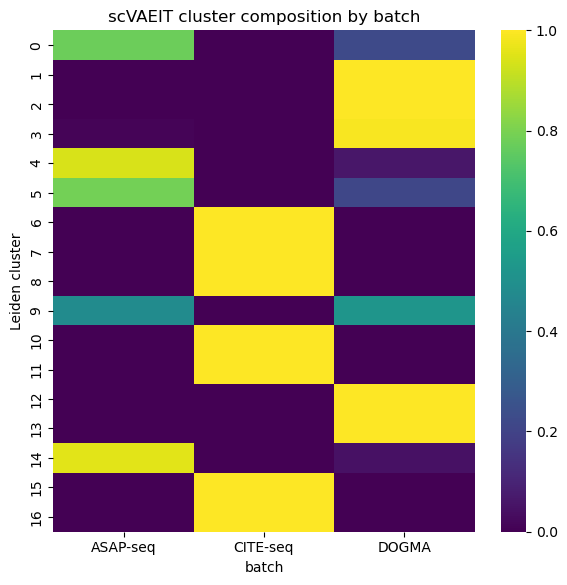

,method,cluster,n_cells
0,scMoMaT,0,3589
1,scMoMaT,1,3136
2,scMoMaT,2,3115
3,scMoMaT,3,2914
4,scMoMaT,4,2266
5,scMoMaT,5,2149
6,scMoMaT,6,2087
7,scMoMaT,7,1921
8,scMoMaT,8,1907
9,scMoMaT,9,1838


In [12]:
method_objects = {
    "scMoMaT": adata_scmomat,
    "MIDAS": adata_midas if "adata_midas" in globals() else None,
    "scVAEIT": adata_scvaeait,
}

cluster_summaries = []
for method_name, adata_obj in method_objects.items():
    if adata_obj is None:
        continue

    if "neighbors" not in adata_obj.uns:
        rep_key = next((k for k in ["X_scmomat", "X_midas", "X_scvaeait"] if k in adata_obj.obsm), None)
        sc.pp.neighbors(adata_obj, use_rep=rep_key, n_neighbors=15 if method_name != "scVAEIT" else 30)

    cluster_key = "leiden_r08"
    sc.tl.leiden(adata_obj, resolution=0.8, key_added=cluster_key, random_state=SEED)
    adata_obj.obs[cluster_key] = adata_obj.obs[cluster_key].astype(str)

    sc.pl.umap(adata_obj, color=cluster_key, show=False, title=f"{method_name} Leiden clusters")
    plt.savefig(FIG_DIR / f"{method_name.lower()}_leiden_clusters.png", dpi=180, bbox_inches="tight")
    plt.show()

    for label_key in ["cell_type", "batch"]:
        ctab = pd.crosstab(adata_obj.obs[cluster_key], adata_obj.obs[label_key], normalize="index")
        plt.figure(figsize=(max(6, 0.5 * ctab.shape[1]), max(4, 0.35 * ctab.shape[0])))
        sns.heatmap(ctab, cmap="viridis", vmin=0, vmax=1)
        plt.title(f"{method_name} cluster composition by {label_key}")
        plt.xlabel(label_key)
        plt.ylabel("Leiden cluster")
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"{method_name.lower()}_cluster_by_{label_key}.png", dpi=180, bbox_inches="tight")
        plt.show()

    cluster_counts = adata_obj.obs[cluster_key].value_counts().sort_index()
    cluster_summaries.append(pd.DataFrame({
        "method": method_name,
        "cluster": cluster_counts.index.astype(str),
        "n_cells": cluster_counts.to_numpy(),
    }))

cluster_summary_df = pd.concat(cluster_summaries, axis=0, ignore_index=True)
display(cluster_summary_df)
cluster_summary_df.to_csv(OUT_DIR / "mosaic_tutorial_cluster_summary.csv", index=False)

## 14. 下游分析示例：缺失模态填补结果可视化

Mosaic integration 的一个重要用途是利用已有模态推断缺失模态。这里的“填补”不是恢复真实实验测量，而是模型根据训练数据学到的跨模态关系给出的预测值。

本教程用两个方法演示：

- MIDAS：在 `predict(impute=True)` 中生成 `x_impt`，即每个 modality 的重构/填补矩阵。MIDAS 文章、代码和教程链接见**方法二**。
- scVAEIT：用 `get_denoised_data()` 生成 decoder 输出，再按 RNA、ADT、ATAC 三个 block 切分。scVAEIT 文章、代码和教程链接见**方法三**。

下面的图显示缺失 modality 对应细胞的平均填补信号分布。它不是判断填补是否“真实”的唯一标准，但可以快速检查：模型是否产生了非空输出、不同 batch 的预测尺度是否异常、某些 modality 是否明显不稳定。

,method,batch,technology,cell_type,modality,availability,mean_imputed_value
0,MIDAS,ASAP-seq,ASAP-seq,DC,rna,missing/imputed,0.807625
1,MIDAS,ASAP-seq,ASAP-seq,DC,rna,missing/imputed,0.640655
2,MIDAS,ASAP-seq,ASAP-seq,DC,rna,missing/imputed,0.630826
3,MIDAS,ASAP-seq,ASAP-seq,B,rna,missing/imputed,0.861655
4,MIDAS,ASAP-seq,ASAP-seq,B,rna,missing/imputed,0.867416


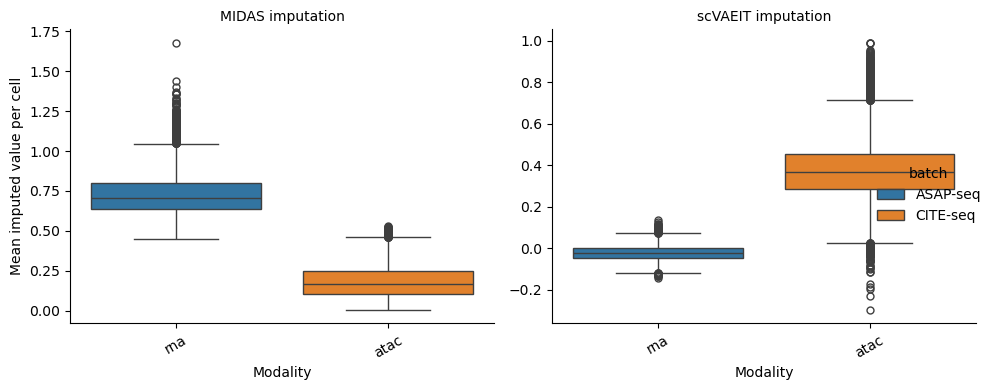

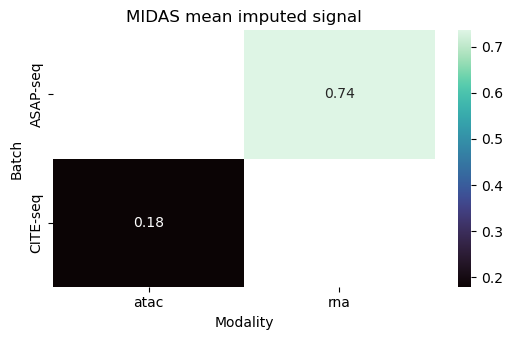

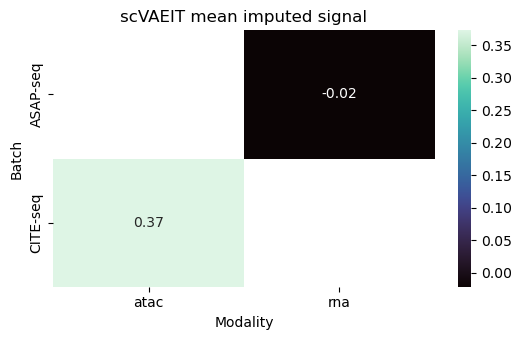

In [13]:
imputation_frames = []

for method_name, subdir, filename in [
    ("MIDAS", "midas_full_default_2000", "midas_imputation_summary.csv"),
    ("scVAEIT", "scvaeait_full_default", "scvaeait_imputation_summary.csv"),
]:
    path = FULL_DIR / subdir / filename
    if path.exists():
        df = pd.read_csv(path, index_col=0)
        df["method"] = method_name
        imputation_frames.append(df)

if imputation_frames:
    imputation_df = pd.concat(imputation_frames, axis=0, ignore_index=True)
    display(imputation_df.head())
    imputation_df.to_csv(OUT_DIR / "mosaic_tutorial_imputation_summary.csv", index=False)

    plot_df = imputation_df[imputation_df["availability"] == "missing/imputed"].copy()
    if plot_df.empty:
        plot_df = imputation_df.copy()

    g = sns.catplot(
        data=plot_df,
        kind="box",
        x="modality",
        y="mean_imputed_value",
        hue="batch",
        col="method",
        sharey=False,
        height=4,
        aspect=1.1,
    )
    g.set_axis_labels("Modality", "Mean imputed value per cell")
    g.set_titles("{col_name} imputation")
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "midas_scvaeait_imputation_boxplots.png", dpi=180, bbox_inches="tight")
    plt.show()

    heat_df = (
        plot_df.groupby(["method", "batch", "modality"], observed=True)["mean_imputed_value"]
        .mean()
        .reset_index()
    )
    for method_name in heat_df["method"].unique():
        sub = heat_df[heat_df["method"] == method_name]
        mat = sub.pivot(index="batch", columns="modality", values="mean_imputed_value")
        plt.figure(figsize=(5.5, 3.5))
        sns.heatmap(mat, cmap="mako", annot=True, fmt=".2f")
        plt.title(f"{method_name} mean imputed signal")
        plt.xlabel("Modality")
        plt.ylabel("Batch")
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"{method_name.lower()}_mean_imputed_signal_heatmap.png", dpi=180, bbox_inches="tight")
        plt.show()
else:
    print("No imputation summary files were found.")

## 15. 如何理解整合结果

看整合结果时，不要只看 batch 是否混合。更合理的判断包括：

- 同一 cell type 是否在低维空间中相对靠近；
- 不同 technology 是否不再完全分裂成几块；
- 已知差异明显的 cell type 是否仍能区分；
- 稀有细胞类型是否被过度拉进大群；
- batch mixing 是否以牺牲生物学结构为代价。

过度整合的典型表现是：不同 cell type 被压成一团，UMAP 看起来很“混合”，但生物学标签消失。批次效应仍然很强的表现是：同一 cell type 按 technology 分成多个孤岛。


## 16. 如何迁移到自己的数据

如果换成自己的 mosaic 数据，需要准备：

- 每个 batch 的细胞 × feature 矩阵；
- 每个 batch 拥有哪些模态；
- batch / sample / donor / technology 标签；
- 如果有，准备 cell type 标签用于评估；
- 每个模态的 feature 名称，例如 gene、peak、ADT；
- 对同一模态，尽量统一 feature 空间，或明确使用共同 feature 子集。

实操建议：先用少量细胞做格式检查，确认矩阵方向、缺失 mask、batch 标签都正确，再扩大到全量训练。


后续正式分析可以在这些完整数据 embedding 上加入更严格的指标，例如 silhouette、batch mixing score、cell type purity、ARI/NMI 等。若迁移到自己的数据，最重要的是准备好每个 batch 的模态矩阵、缺失模态标记、batch/technology 标签和每个模态的 feature 名称；先用少量细胞做格式检查，再扩大到全量训练。